In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

#In this project, lets imagine we are throwing a party, and we are letting the shuffle feature on spotify dictate what music is played. 
# Thus, we want to know the probability that we will withdraw a song with an average tempo of 140 bpm or lower in a givem sample of 30, 
# which is too slow for an upbeat party! 


In [25]:
#A simple function to return the mean or variance of the dataset in question 

def choose_statistic(x, sample_stat_text):
  if sample_stat_text == "Mean":
    return np.mean(x)
  elif sample_stat_text == "std":
    return x.std()
  else:
    raise Exception('Make sure to input "Mean" or "Variance"')


# A function to plot the population distribution

def population_distribution(population_data):
  sns.histplot(population_data, stat='density')
  plt.title(f"Population Distribution")
  plt.xlabel('')
  plt.show()
  plt.clf()

# A function to plot the distribution, of the means of random samples of 30, taken from our population (500 * n = 30)  
def sampling_distribution(population_data, samp_size, stat):
  sample_stats = []
  for i in range(500):
    samp = np.random.choice(population_data, samp_size, replace = False)
    sample_stat = choose_statistic(samp, stat)
    # add sample_stat to the sample_stats list
    sample_stats.append(sample_stat)
  pop_statistic = round(choose_statistic(population_data, stat),2)
  # plot the sampling distribution
  sns.histplot(sample_stats, stat='density')
  # informative title for the sampling distribution
  plt.title(f"Sampling Distribution of the {stat} \nMean of the Sample {stat}s: {round(np.mean(sample_stats), 2)} \n Population {stat}: {pop_statistic}")
  plt.axvline(pop_statistic,color='g',linestyle='dashed', label=f'Population {stat}')
  # plot the mean of the chosen sample statistic for the sampling distribution
  plt.axvline(np.mean(sample_stats),color='orange',linestyle='dashed', label=f'Mean of the Sample {stat}s')
  plt.legend()
  plt.show()
  plt.clf()
  df = pd.DataFrame(sample_stats, columns =["MyValues"])
  print(df.std())

     tempo  danceability  energy  instrumentalness  liveness  valence
0  156.985         0.831   0.814          0.013400    0.0556   0.3890
1  115.080         0.719   0.493          0.000000    0.1180   0.1240
2  218.050         0.850   0.893          0.000004    0.3720   0.0391
3  186.948         0.476   0.781          0.000000    0.1140   0.1750
4  147.988         0.798   0.624          0.000000    0.1660   0.5910


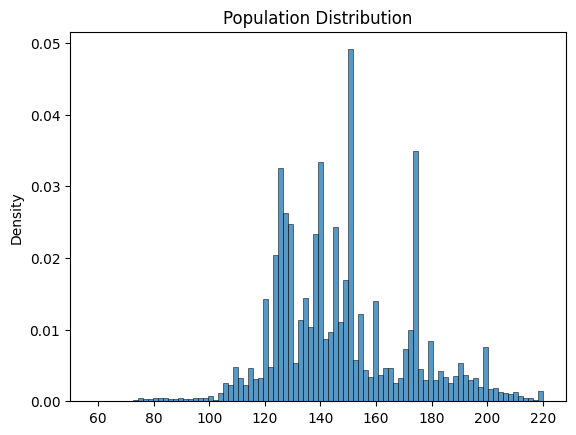

None 147.4740559035575


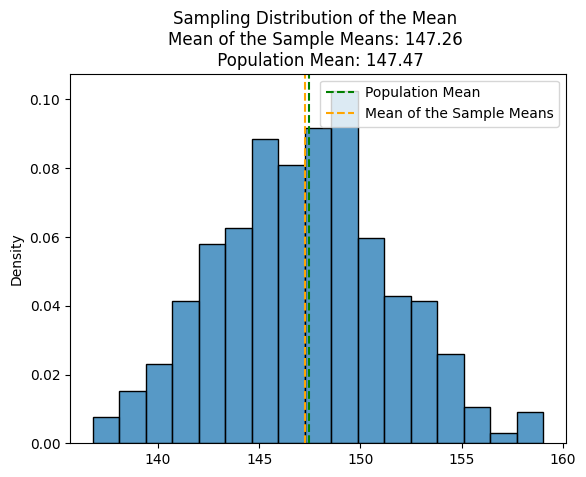

MyValues    4.213298
dtype: float64
None


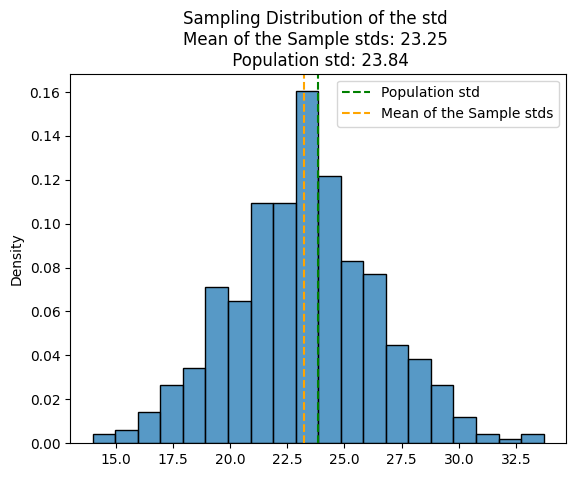

MyValues    3.219232
dtype: float64
None


<Figure size 640x480 with 0 Axes>

In [26]:
# Loading in our dataset and getting the relevant column 
spotify_data = pd.read_csv("spotify_data.csv")
print(spotify_data.head())
song_tempos = spotify_data["tempo"]

# Plotting the population distribution with the mean labeled
print(population_distribution(song_tempos), choose_statistic(song_tempos, "Mean"))

# Plotting the distribution of the means of each sample (500 * N = 30) 
print(sampling_distribution(song_tempos, 30, "Mean"))
print(sampling_distribution(song_tempos, 30, "std"))

#Just a sidenote, this demonstrates that the means and stds of our 500 samples of 30 are approximatelty equal to the true population STD and mean, 
#and they are normally distributed. This is some intuitive proof as to why the Central Limit Theorem allows us to make predictions about the 
# population mean and std (which we often do not know) from samples!!. 

In [27]:
# Nevertheless, since we know the population mean and std in our dataset, we can use this to make informed judgements about the tempo of a randomly 
#drawn sample of 30. We plug this into the equation for standard error.  

population_mean = song_tempos.mean()
population_std = song_tempos.std()  
standard_error = population_std / (30**0.5)

# Now we can use the cumulative density function to make predicitons on the probability of getting some tempo on a random sample of 30

# This will tell us the probability of getting 140 bpm or lower in a sample of 30 songs 
print(stats.norm.cdf(140, population_mean, standard_error))

# The probability of getting an average tempo of 150bpm or higher from a sample of 30 songs
print(1  - stats.norm.cdf(150, population_mean, standard_error))

# The probability that a 30 sample size has a minimum less than 130bpm
print(stats.norm.cdf(130, 105.17, standard_error))

0.04300540443699053
0.28088259300283225
0.9999999941338562
